In [2]:
import pandas as pd
import os

# 1. 파일 경로 설정 및 확인
# '__file__'은 일반 Python 스크립트에서 현재 파일 경로를 제공합니다.
# 주피터/Colab 환경에서는 'os.getcwd()'를 사용할 수도 있습니다.
try:
    # 일반 .py 파일 실행 시
    base_dir = os.path.dirname(os.path.abspath(__file__)) 
except NameError:
    # 주피터 노트북/IPython 환경 시 (현재 작업 디렉토리)
    base_dir = os.getcwd() 

# 'data_csv' 폴더와 파일명을 결합하여 완전한 경로를 생성
file_path = os.path.join(base_dir, 'data_csv', '강원특별자치도_일반음식점.csv')

print(f"시도할 파일 경로: {file_path}")

# 2. 파일 존재 여부 확인 (디버깅)
if not os.path.exists(file_path):
    print("\n🚨 경로에 파일이 존재하지 않습니다. 폴더 이름이나 파일명이 정확한지 확인하세요.")
    # 경로가 잘못되었을 가능성이 높으므로 여기서 함수를 종료하거나 대체 경로를 시도해야 합니다.
else:
    # 3. 파일 읽기 (원래 시도했던 CP949 인코딩 사용)
    try:
        data = pd.read_csv(file_path, encoding='CP949', low_memory=False)
        print("✅ 파일 로드 성공!")
        data_columns = list(data.columns)
        # print(data_columns)

    except UnicodeDecodeError:
        print("\n⚠️ CP949 인코딩 오류 발생! UTF-8로 다시 시도합니다.")
        data = pd.read_csv(file_path, encoding='utf-8', low_memory=False)
        data_columns = list(data.columns)

시도할 파일 경로: c:\Users\mingyu\Desktop\company_data1\company_data\second_week\data_csv\강원특별자치도_일반음식점.csv
✅ 파일 로드 성공!


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98965 entries, 0 to 98964
Data columns (total 48 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   번호               98965 non-null  int64  
 1   개방서비스명           98965 non-null  object 
 2   개방서비스아이디         98965 non-null  object 
 3   개방자치단체코드         98965 non-null  int64  
 4   관리번호             98965 non-null  object 
 5   인허가일자            98965 non-null  object 
 6   인허가취소일자          0 non-null      float64
 7   영업상태구분코드         98965 non-null  int64  
 8   영업상태명            98965 non-null  object 
 9   상세영업상태코드         98965 non-null  int64  
 10  상세영업상태명          98965 non-null  object 
 11  폐업일자             67209 non-null  object 
 12  휴업시작일자           0 non-null      float64
 13  휴업종료일자           0 non-null      float64
 14  재개업일자            0 non-null      float64
 15  소재지전화            65927 non-null  object 
 16  소재지면적            91261 non-null  float64
 17  소재지우편번호     

In [4]:
import numpy as np
total_size = data['폐업일자'].isnull().size
total_size
def make_autopct_with_count(pct):
    absolute_count = int(np.round(pct*total_size/100))
    return f"{pct:.1f}%\n({absolute_count}명)"

In [5]:
make_autopct_with_count(20)

'20.0%\n(19793명)'

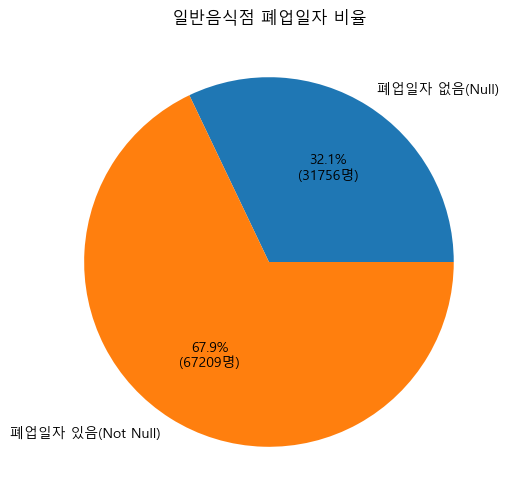

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')  # 윈도우 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

# null / not-null 개수 집계
counts = data['폐업일자'].isnull().value_counts()

# value_counts()는 {True: N1, False: N2} 형태이므로 라벨 지정
labels = ['폐업일자 없음(Null)', '폐업일자 있음(Not Null)']

# 순서 맞추기 위해 정렬
sizes = [counts.get(True, 0), counts.get(False, 0)]

# Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct=make_autopct_with_count)
plt.title('일반음식점 폐업일자 비율')
plt.savefig('./data_analysis/일반음식점폐업_파이차트.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
data.set_index('사업장명')
columns = ['번호','개방서비스명','개방서비스아이디', '개방자치단체코드']

In [8]:
null_cols = data.columns[data.isnull().all()]
null_columns = list(null_cols)
data.drop(columns = null_columns,inplace = True)
data.set_index('사업장명',inplace = True)


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98965 entries, 대감집 to 산천어 회센터(3)
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   번호               98965 non-null  int64  
 1   개방서비스명           98965 non-null  object 
 2   개방서비스아이디         98965 non-null  object 
 3   개방자치단체코드         98965 non-null  int64  
 4   관리번호             98965 non-null  object 
 5   인허가일자            98965 non-null  object 
 6   영업상태구분코드         98965 non-null  int64  
 7   영업상태명            98965 non-null  object 
 8   상세영업상태코드         98965 non-null  int64  
 9   상세영업상태명          98965 non-null  object 
 10  폐업일자             67209 non-null  object 
 11  소재지전화            65927 non-null  object 
 12  소재지면적            91261 non-null  float64
 13  소재지우편번호          8 non-null      object 
 14  소재지전체주소          98757 non-null  object 
 15  도로명전체주소          60469 non-null  object 
 16  도로명우편번호          59504 non-null  float64
 17  최종수정시점    

In [34]:
# 1. 이상치 경계 계산 (기존 코드 유지)
Q1 = data['소재지면적'].quantile(0.25)
Q3 = data['소재지면적'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. 이상치를 제거한 새로운 DataFrame 생성
# 하한 경계(lower_bound)보다 크거나 같고 AND 상한 경계(upper_bound)보다 작거나 같은 
# '소재지면적'을 가진 행만 선택합니다.
data_cleaned = data[
    (data['소재지면적'] >= lower_bound) & 
    (data['소재지면적'] <= upper_bound)
].copy() # SettingWithCopyWarning 방지를 위해 copy() 사용 권장

## 이상치 제거전

In [35]:

data = data[data['소재지면적'] != 0].copy() 


In [38]:
data['소재지면적'].describe()

count    89818.000000
mean        81.961098
std        103.231060
min          0.600000
25%         34.640000
50%         59.900000
75%         97.120000
max       5468.990000
Name: 소재지면적, dtype: float64

## 이상치 제거후

In [41]:
data_cleaned['소재지면적'].describe()
data_cleaned.to_csv('이상치제거한_일반음식점.csv')

In [40]:
data_cleaned['소재지면적'].count()/ data['소재지면적'].count()

np.float64(0.941559598298782)